<a href="https://colab.research.google.com/github/paulahruizpro-ux/telecom-x-ii/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telecom X - Parte 2**

Missão:
- Desenvolver modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços




---



##📊 **Importação e extração**

In [1]:
!pip install pandas scikit-learn imblearn

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
dados = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Telecom 2/dados_tratados_telecom2.csv')

In [5]:
pd.set_option('display.max_columns', None)
dados.head()

,customer_id,churn,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,internet_online_security,internet_online_backup,internet_device_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [6]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 7267 non-null   object 
 1   churn                       7043 non-null   object 
 2   customer_gender             7267 non-null   object 
 3   customer_senior_citizen     7267 non-null   int64  
 4   customer_partner            7267 non-null   object 
 5   customer_dependents         7267 non-null   object 
 6   customer_tenure             7267 non-null   int64  
 7   phone_phone_service         7267 non-null   object 
 8   phone_multiple_lines        7267 non-null   object 
 9   internet_internet_service   7267 non-null   object 
 10  internet_online_security    7267 non-null   object 
 11  internet_online_backup      7267 non-null   object 
 12  internet_device_protection  7267 non-null   object 
 13  internet_tech_support       7267 



---



##**Preparação dos dados**

In [7]:
#Quais colunas têm NaN
nan_cols = dados.columns[dados.isna().any()].to_list()
print("Colunas com NaN:", nan_cols)

Colunas com NaN: ['churn', 'account_charges_total']


In [8]:
#Remoção de Nan do Churn
dados = dados[dados['churn'].notna()].copy()

print(f'Linhas após limpeza: {len(dados)}')
print(f'Nan em churn: {dados['churn'].isna().sum()}')

Linhas após limpeza: 7043
Nan em churn: 0


In [9]:
# Imputação de NaN do account_charges_total
from sklearn.impute import SimpleImputer

#criar imputer com estratégia 'median'

imputer = SimpleImputer(strategy='median')

#seleciona coluna com Nan e com ravel substitui os valores originais
#pelos valores limpos

dados['account_charges_total'] = imputer.fit_transform(
    dados[['account_charges_total']]
).ravel()
print("NaNs após imputação:", dados['account_charges_total'].isna().sum())


NaNs após imputação: 0


In [10]:
dados.columns

Index(['customer_id', 'churn', 'customer_gender', 'customer_senior_citizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phone_service', 'phone_multiple_lines',
       'internet_internet_service', 'internet_online_security',
       'internet_online_backup', 'internet_device_protection',
       'internet_tech_support', 'internet_streaming_tv',
       'internet_streaming_movies', 'account_contract',
       'account_paperless_billing', 'account_payment_method',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [11]:
dados.shape

(7043, 21)

In [12]:
#Remoção de colunas irrelevantes
dados = dados.drop(columns = 'customer_id')

In [13]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   churn                       7043 non-null   object 
 1   customer_gender             7043 non-null   object 
 2   customer_senior_citizen     7043 non-null   int64  
 3   customer_partner            7043 non-null   object 
 4   customer_dependents         7043 non-null   object 
 5   customer_tenure             7043 non-null   int64  
 6   phone_phone_service         7043 non-null   object 
 7   phone_multiple_lines        7043 non-null   object 
 8   internet_internet_service   7043 non-null   object 
 9   internet_online_security    7043 non-null   object 
 10  internet_online_backup      7043 non-null   object 
 11  internet_device_protection  7043 non-null   object 
 12  internet_tech_support       7043 non-null   object 
 13  internet_streaming_tv       7043 non-n

In [14]:
dados.columns

Index(['churn', 'customer_gender', 'customer_senior_citizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phone_service', 'phone_multiple_lines',
       'internet_internet_service', 'internet_online_security',
       'internet_online_backup', 'internet_device_protection',
       'internet_tech_support', 'internet_streaming_tv',
       'internet_streaming_movies', 'account_contract',
       'account_paperless_billing', 'account_payment_method',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

In [15]:
dados.nunique()

,0
churn,2
customer_gender,2
customer_senior_citizen,2
customer_partner,2
customer_dependents,2
customer_tenure,73
phone_phone_service,2
phone_multiple_lines,3
internet_internet_service,3
internet_online_security,3


##**Encoding**

In [16]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [17]:
colunas = dados.columns

In [18]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['churn','customer_gender','customer_partner','customer_dependents',
     'phone_phone_service', 'phone_multiple_lines', 'internet_internet_service',
     'internet_online_security', 'internet_online_backup', 'internet_device_protection',
     'internet_tech_support', 'internet_streaming_tv',
     'internet_streaming_movies', 'account_contract',
     'account_paperless_billing', 'account_payment_method']
),
    remainder = 'passthrough',
    sparse_threshold = 0)

In [19]:
dados_encoded = one_hot.fit_transform(dados)

In [20]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__churn_Yes', 'onehotencoder__customer_gender_Male',
       'onehotencoder__customer_partner_Yes',
       'onehotencoder__customer_dependents_Yes',
       'onehotencoder__phone_phone_service_Yes',
       'onehotencoder__phone_multiple_lines_No',
       'onehotencoder__phone_multiple_lines_No phone service',
       'onehotencoder__phone_multiple_lines_Yes',
       'onehotencoder__internet_internet_service_DSL',
       'onehotencoder__internet_internet_service_Fiber optic',
       'onehotencoder__internet_internet_service_No',
       'onehotencoder__internet_online_security_No',
       'onehotencoder__internet_online_security_No internet service',
       'onehotencoder__internet_online_security_Yes',
       'onehotencoder__internet_online_backup_No',
       'onehotencoder__internet_online_backup_No internet service',
       'onehotencoder__internet_online_backup_Yes',
       'onehotencoder__internet_device_protection_No',
       'onehotencoder__internet_device_protec

In [21]:
dados_encoded= pd.DataFrame(dados_encoded,columns= one_hot.get_feature_names_out(colunas))
dados_encoded

,onehotencoder__churn_Yes,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,onehotencoder__internet_online_security_No,onehotencoder__internet_online_security_No internet service,onehotencoder__internet_online_security_Yes,onehotencoder__internet_online_backup_No,onehotencoder__internet_online_backup_No internet service,onehotencoder__internet_online_backup_Yes,onehotencoder__internet_device_protection_No,onehotencoder__internet_device_protection_No internet service,onehotencoder__internet_device_protection_Yes,onehotencoder__internet_tech_support_No,onehotencoder__internet_tech_support_No internet service,onehotencoder__internet_tech_support_Yes,onehotencoder__internet_streaming_tv_No,onehotencoder__internet_streaming_tv_No internet service,onehotencoder__internet_streaming_tv_Yes,onehotencoder__internet_streaming_movies_No,onehotencoder__internet_streaming_movies_No internet service,onehotencoder__internet_streaming_movies_Yes,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total
0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,9.0,65.60,593.30
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,59.90,542.40
2,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0,73.90,280.85
3,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,13.0,98.00,1237.85
4,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,3.0,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0,55.15,742.90
7039,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,22.0,85.10,1873.70
7040,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,50.30,92.75
7041,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,67.0,67.85,4627.65




---



## **Proporção de Cancelamento (Churn)**

Calculou-se a proporção de cancelamento e de permanência dos clientes, para compreender se o dataset está balanceado ou não.

In [22]:
dados_encoded['onehotencoder__churn_Yes'].value_counts()

,count
onehotencoder__churn_Yes,
0.0,5174
1.0,1869


In [23]:
print('Proporção de cancelamentos:')
print()
contagem = dados_encoded['onehotencoder__churn_Yes'].value_counts()
porcentagem = dados_encoded['onehotencoder__churn_Yes'].value_counts(normalize=True) * 100

#juntar duas series com concat()
#axis=1 coloca em colunas
#keys nomeia as colunas

tabela = pd.concat([contagem, porcentagem.round(1)], axis=1,
                   keys=['Contagem', 'Porcentagem(%)'])

print(tabela.reset_index(drop=True))

Proporção de cancelamentos:

   Contagem  Porcentagem(%)
0      5174            73.5
1      1869            26.5


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

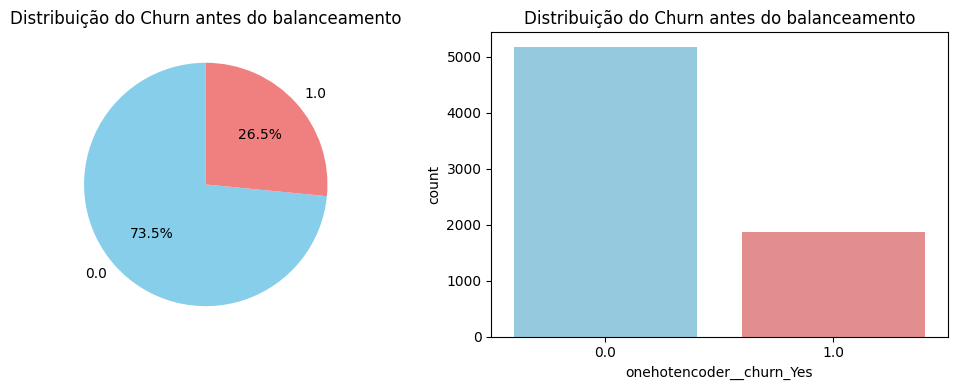

In [25]:
#Plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

#Plot pizza
pie_colors=['skyblue','lightcoral']
axes[0].pie(dados_encoded['onehotencoder__churn_Yes'].value_counts(), labels=dados_encoded['onehotencoder__churn_Yes'].value_counts().index, autopct='%1.1f%%',
            startangle=90, colors=pie_colors)
axes[0].set_title('Distribuição do Churn antes do balanceamento')

#Plot de contagem

countplot_colors = sns.color_palette(pie_colors)
sns.countplot(x='onehotencoder__churn_Yes', hue = 'onehotencoder__churn_Yes',
              data = dados_encoded, palette = countplot_colors, ax=axes[1],
              legend=False)
axes[1].set_title('Distribuição do Churn antes do balanceamento')

plt.tight_layout()
plt.show()


A análise da distribuição da variável alvo indicou desbalanceamento entre as classes, com maior proporção de clientes que permaneceram. Esse cenário pode induzir o modelo a privilegiar a classe majoritária, comprometendo sua capacidade de identificar corretamente os casos de cancelamento (classe minoritária).

##**Separação dos dados entre explicativas(X) e alvo(y)**

Antes de realizar o balanceamento das classes, os dados foram divididos em conjuntos de treino e teste. Essa etapa é necessária para evitar vazamento de dados, garantindo que o balanceamento seja aplicado apenas no conjunto de treino e que a avaliação do modelo seja feita sobre dados não utilizados no processo de ajuste.

In [26]:
X = dados_encoded.drop('onehotencoder__churn_Yes', axis = 1)
y = dados_encoded[['onehotencoder__churn_Yes']]

X.shape, y.shape

((7043, 40), (7043, 1))

In [27]:
#Dividir dados entre treino e teste
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,y, test_size=0.2, random_state = 42)

X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape

((5634, 40), (1409, 40), (5634, 1), (1409, 1))



---



##**Balanceamento de Classes**

Em cenários como esse, modelos de classificação tendem a privilegiar a classe majoritária, podendo apresentar elevada acurácia, porém baixo desempenho na identificação da classe minoritária — que, neste caso, corresponde ao evento de maior interesse estratégico (churn).

Para mitigar esse viés, optou-se pela aplicação da técnica de oversampling SMOTE, que gera exemplos sintéticos da classe minoritária com base em seus vizinhos mais próximos, promovendo maior equilíbrio na base de treinamento sem simplesmente replicar observações existentes.

In [28]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

def validacao_cruzada(modelo, X, y, oversampling=False):
  #divide em 10 partes iguais
  kfold = KFold(n_splits=10)
  acuracias_split = []

#kfold gera pares de índices de treino e de validação

#iterando sobre os splits
  for idx, (idx_treino, idx_validacao) in enumerate(kfold.split(X)):
    X_split_treino = X.iloc[idx_treino, :]
    y_split_treino = y.iloc[idx_treino, :]

#oversampling só no split de treino
    if oversampling:
      sm = SMOTE(random_state=42)
      X_split_treino, y_split_treino = sm.fit_resample(X_split_treino, y_split_treino)

    modelo.fit(X_split_treino, y_split_treino.values.flatten())

    X_split_validacao = X.iloc[idx_validacao, :]
    y_split_validacao = y.iloc[idx_validacao, :]

    predicoes = modelo.predict(X_split_validacao)

    acuracia_split = accuracy_score(y_split_validacao, predicoes)

    acuracias_split.append(acuracia_split)

    print(f'A acurácia do split {idx}:{acuracia_split}')

  return acuracias_split




In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier
from statistics import mean

#criando o modelo
modelo_hgb = HistGradientBoostingClassifier()

In [30]:
media_acuracia_sem_smote = mean(validacao_cruzada(modelo_hgb, X_treino, y_treino, oversampling = False))

A acurácia do split 0:0.8014184397163121
A acurácia do split 1:0.7925531914893617
A acurácia do split 2:0.7960992907801419
A acurácia do split 3:0.8014184397163121
A acurácia do split 4:0.7779751332149201
A acurácia do split 5:0.7744227353463587
A acurácia do split 6:0.7957371225577264
A acurácia do split 7:0.7975133214920072
A acurácia do split 8:0.7886323268206039
A acurácia do split 9:0.7904085257548845


In [31]:
media_acuracia_sem_smote

0.7916178526888629

In [32]:
media_acuracia_com_smote = mean(validacao_cruzada(modelo_hgb, X_treino, y_treino, oversampling = True))

A acurácia do split 0:0.8120567375886525
A acurácia do split 1:0.7695035460992907
A acurácia do split 2:0.7783687943262412
A acurácia do split 3:0.7943262411347518
A acurácia do split 4:0.7904085257548845
A acurácia do split 5:0.7957371225577264
A acurácia do split 6:0.7921847246891652
A acurácia do split 7:0.7921847246891652
A acurácia do split 8:0.7921847246891652
A acurácia do split 9:0.783303730017762


In [33]:
media_acuracia_com_smote

0.7900258871546805

In [34]:
f'Sem smote: {media_acuracia_sem_smote:.02f}, Com smote: {media_acuracia_com_smote:.02f}'

'Sem smote: 0.79, Com smote: 0.79'

In [35]:
#Balancear os dados
sm = SMOTE(random_state=42)
X_treino_balanceado, y_treino_balanceado = sm.fit_resample(X_treino, y_treino)



---



##**Normalização dos dados**

Considerando que o conjunto de dados apresenta variáveis numéricas em diferentes escalas — como tempo de contrato, cobranças mensais e valor total acumulado — optou-se pela normalização dos dados.

A padronização foi necessária para evitar que variáveis com maior magnitude numérica exercessem influência desproporcional no processo de otimização do modelo, especialmente em algoritmos sensíveis à escala, como a Regressão Logística.

Dessa forma, garantiu-se que todas as variáveis contribuíssem de maneira equilibrada para o treinamento do modelo.

In [36]:
from sklearn.preprocessing import StandardScaler


In [66]:
#Normalização

scaler = StandardScaler()
scaler.fit(X_treino_balanceado)

X_treino_norm = scaler.transform(X_treino_balanceado)
X_teste_norm = scaler.transform(X_teste)

In [38]:
X_treino_balanceado

,onehotencoder__customer_gender_Male,onehotencoder__customer_partner_Yes,onehotencoder__customer_dependents_Yes,onehotencoder__phone_phone_service_Yes,onehotencoder__phone_multiple_lines_No,onehotencoder__phone_multiple_lines_No phone service,onehotencoder__phone_multiple_lines_Yes,onehotencoder__internet_internet_service_DSL,onehotencoder__internet_internet_service_Fiber optic,onehotencoder__internet_internet_service_No,onehotencoder__internet_online_security_No,onehotencoder__internet_online_security_No internet service,onehotencoder__internet_online_security_Yes,onehotencoder__internet_online_backup_No,onehotencoder__internet_online_backup_No internet service,onehotencoder__internet_online_backup_Yes,onehotencoder__internet_device_protection_No,onehotencoder__internet_device_protection_No internet service,onehotencoder__internet_device_protection_Yes,onehotencoder__internet_tech_support_No,onehotencoder__internet_tech_support_No internet service,onehotencoder__internet_tech_support_Yes,onehotencoder__internet_streaming_tv_No,onehotencoder__internet_streaming_tv_No internet service,onehotencoder__internet_streaming_tv_Yes,onehotencoder__internet_streaming_movies_No,onehotencoder__internet_streaming_movies_No internet service,onehotencoder__internet_streaming_movies_Yes,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paperless_billing_Yes,onehotencoder__account_payment_method_Bank transfer (automatic),onehotencoder__account_payment_method_Credit card (automatic),onehotencoder__account_payment_method_Electronic check,onehotencoder__account_payment_method_Mailed check,remainder__customer_senior_citizen,remainder__customer_tenure,remainder__account_charges_monthly,remainder__account_charges_total
0,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.0,1.0,0.000000,0.0,1.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000,0.0,1.000000,1.000000,0.0,0.000000,1.000000,0.000000,0.0,0.000000,0.0,0.000000,1.000000,0.0,0.0,3.000000,89.850000,248.400000
1,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000,0.0,1.000000,1.000000,0.000000,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.0,36.000000,84.750000,3050.150000
2,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000,0.0,1.000000,0.000000,0.0,1.000000,1.000000,0.000000,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.0,49.000000,95.600000,4783.500000
3,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,0.000000,0.0,1.000000,1.000000,0.000000,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.0,7.000000,79.300000,523.150000
4,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,1.0,0.0,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.000000,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.0,2.000000,45.000000,89.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8271,1.000000,0.000000,0.625330,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.0,1.0,0.0,0.0,0.374670,0.0,0.625330,1.000000,0.0,0.000000,0.625330,0.0,0.374670,1.000000,0.0,0.000000,1.000000,0.0,0.000000,1.000000,0.000000,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.0,1.000000,75.556068,75.556068
8272,0.747078,0.747078,0.747078,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,1.0,0.0,0.0,1.000000,0.0,0.000000,1.000000,0.0,0.000000,0.747078,0.0,0.252922,1.000000,0.0,0.000000,1.000000,0.0,

##**Análise de Correlação**

In [39]:
#Correlação
corr = dados_encoded.corr()

In [40]:
#Quais fatores estão mais correlacionados com o churn?

corr['onehotencoder__churn_Yes'].sort_values(ascending=False)

,onehotencoder__churn_Yes
onehotencoder__churn_Yes,1.000000
onehotencoder__account_contract_Month-to-month,0.405103
onehotencoder__internet_online_security_No,0.342637
onehotencoder__internet_tech_support_No,0.337281
onehotencoder__internet_internet_service_Fiber optic,0.308020
onehotencoder__account_payment_method_Electronic check,0.301919
onehotencoder__internet_online_backup_No,0.268005
onehotencoder__internet_device_protection_No,0.252481
remainder__account_charges_monthly,0.193356
onehotencoder__account_paperless_billing_Yes,0.191825


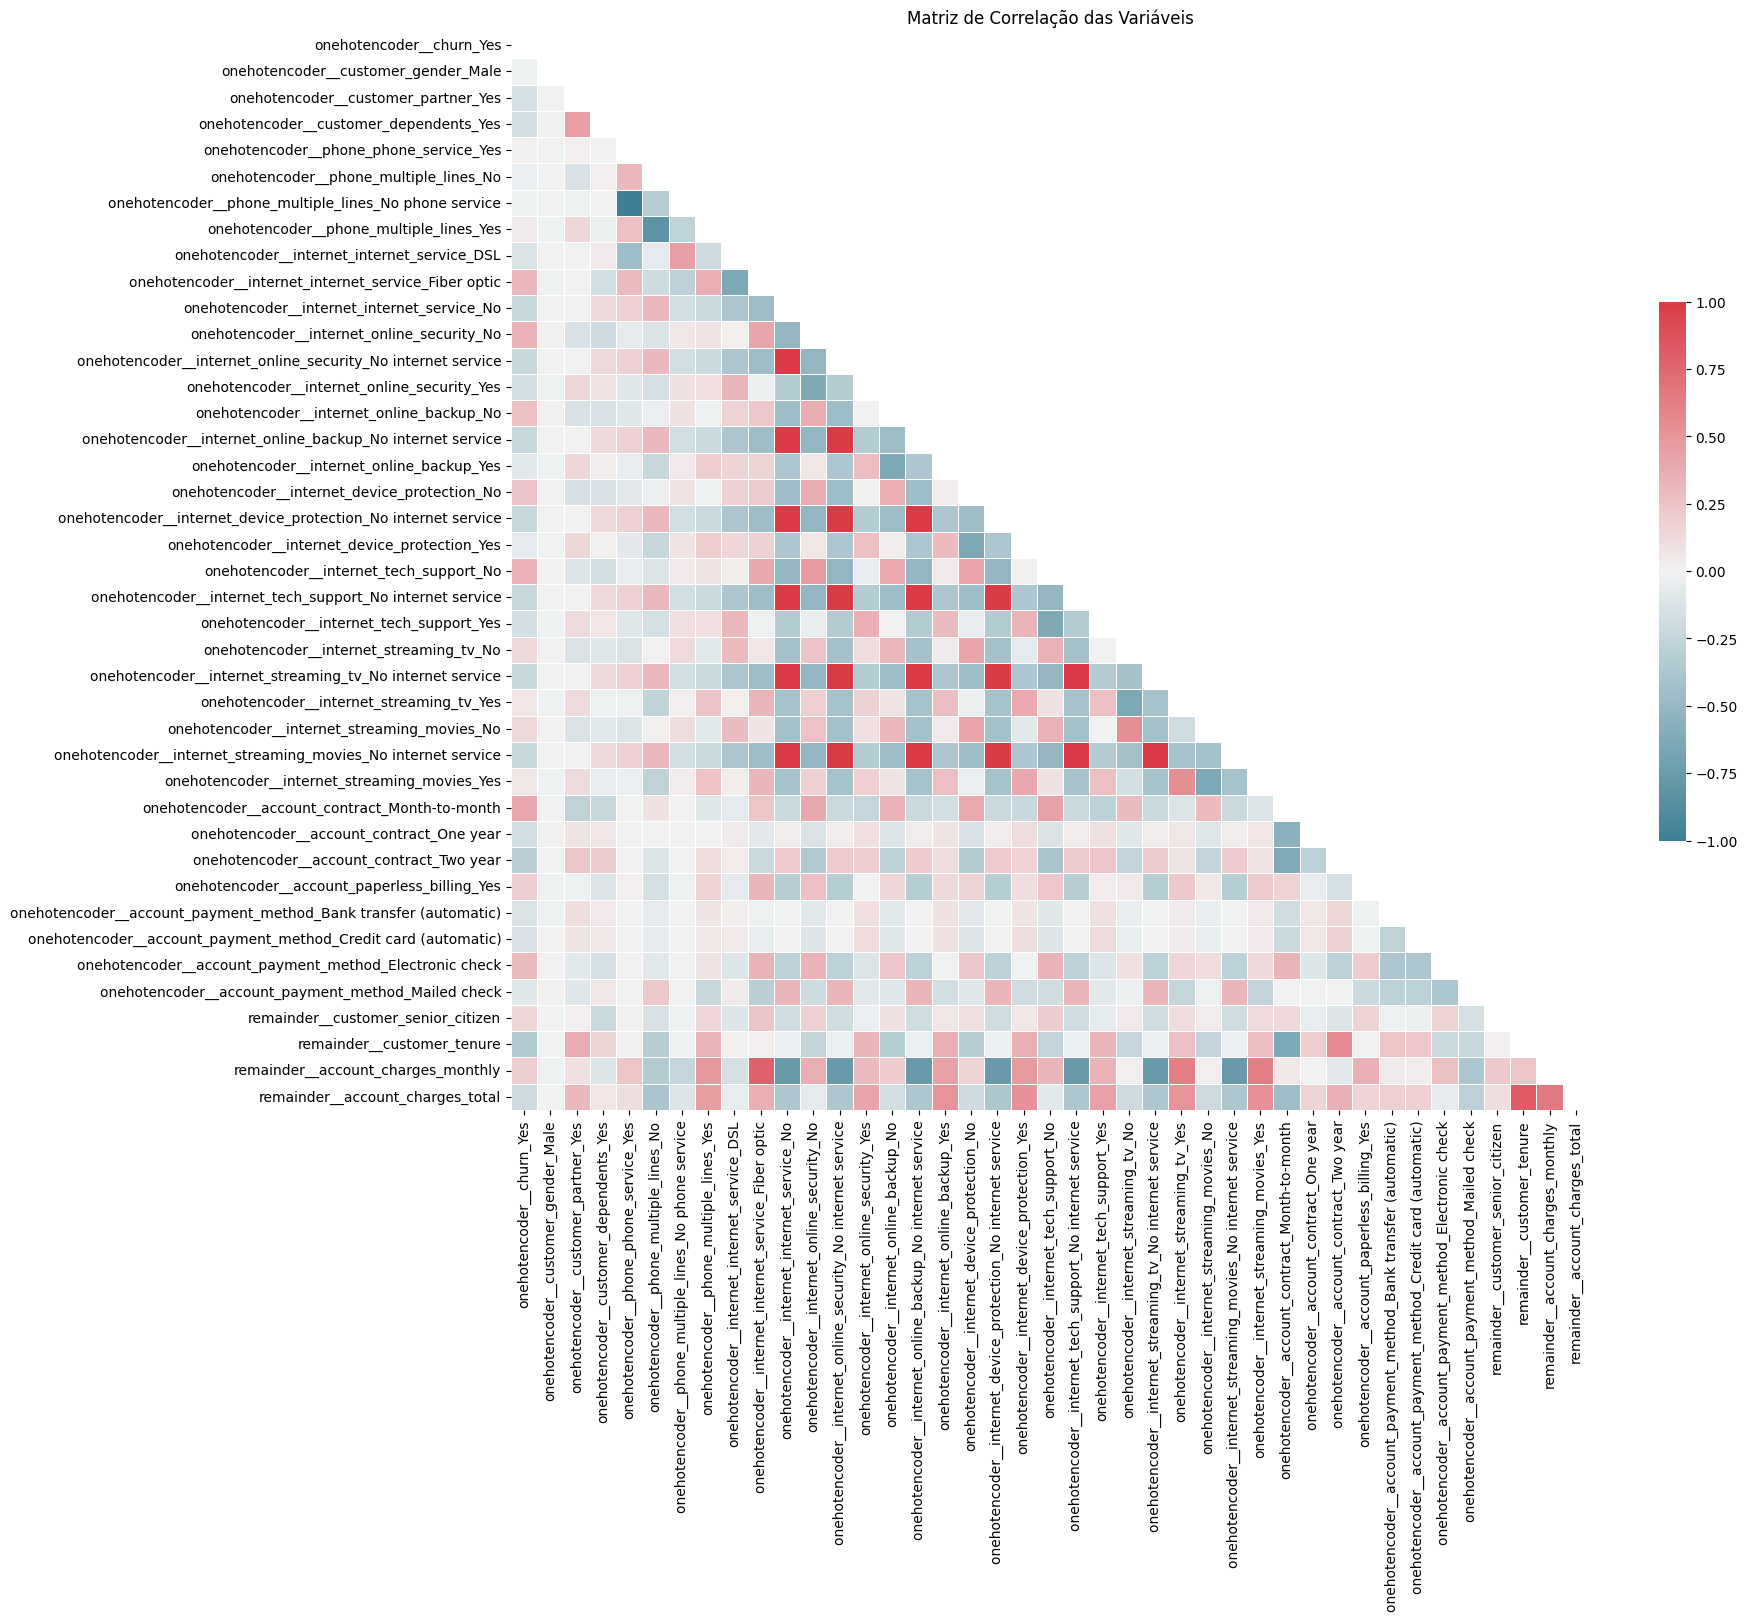

In [41]:
#Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

#Configurar figura do matplotlib
f, ax = plt.subplots(figsize=(18,14))

#Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220,10, as_cmap=True)

sns.heatmap(corr, mask=mascara,cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=False, cbar_kws={'shrink':.5})
plt.title('Matriz de Correlação das Variáveis')
#Exibir o mapa de calor
plt.show()


In [42]:
corr_churn = corr['onehotencoder__churn_Yes']\
                .drop('onehotencoder__churn_Yes')

top3_pos= corr_churn.sort_values(ascending=False).head(3)
top3_pos


,onehotencoder__churn_Yes
onehotencoder__account_contract_Month-to-month,0.405103
onehotencoder__internet_online_security_No,0.342637
onehotencoder__internet_tech_support_No,0.337281


In [43]:
top3_neg = corr_churn.sort_values(ascending=True).head(3)
top3_neg

,onehotencoder__churn_Yes
remainder__customer_tenure,-0.352229
onehotencoder__account_contract_Two year,-0.302253
onehotencoder__internet_internet_service_No,-0.227890


A análise de matriz de correlação revelou que contratos mensais e a ausência de serviços adicionais (segurança online e suporte técnico) apresentam associação positiva com a evasão.

Por outro lado, maior tempo de relacionamento e contratos de longo prazo demonstraram correlação negatia, indicando potencial de retenção. Essas variáveis são fortes candidatas para o modelo preditivo.

In [44]:
top6 = pd.concat([top3_pos, top3_neg])

top6_df = top6.reset_index()
top6_df.columns = 'Variável', 'Correlação com Churn'

top6_df

,Variável,Correlação com Churn
0,onehotencoder__account_contract_Month-to-month,0.405103
1,onehotencoder__internet_online_security_No,0.342637
2,onehotencoder__internet_tech_support_No,0.337281
3,remainder__customer_tenure,-0.352229
4,onehotencoder__account_contract_Two year,-0.302253
5,onehotencoder__internet_internet_service_No,-0.227890




---



**Análises direcionadas**

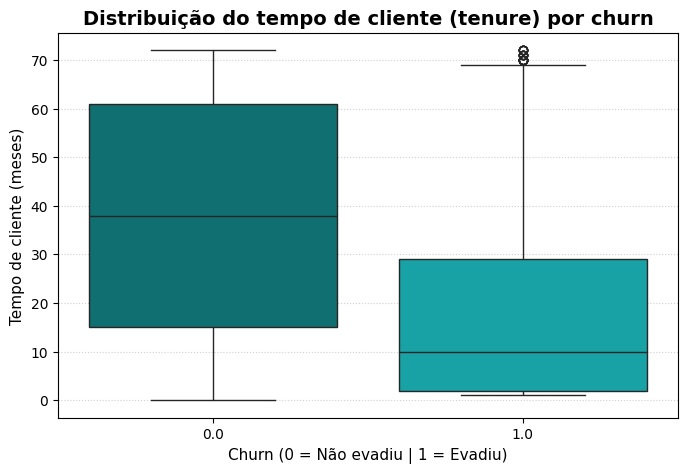

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='onehotencoder__churn_Yes',
    y='remainder__customer_tenure',
    data = dados_encoded,
    hue='onehotencoder__churn_Yes',
    palette=['#007e80', '#00b9bd'],
    legend=False
)

plt.title('Distribuição do tempo de cliente (tenure) por churn', fontsize=14, weight='bold')
plt.xlabel('Churn (0 = Não evadiu | 1 = Evadiu)', fontsize=11)
plt.ylabel('Tempo de cliente (meses)', fontsize=11)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

paleta https://paletadecores.com/paleta/fb6900/f63700/004853/007e80/00b9bd/

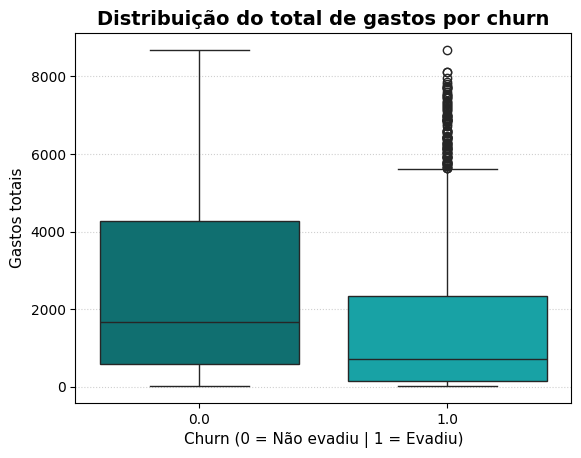

In [46]:
sns.boxplot(x='onehotencoder__churn_Yes',
            y='remainder__account_charges_total',
            data=dados_encoded,
            palette=['#007e80', '#00b9bd'],
            hue ='onehotencoder__churn_Yes',
            legend=False
)


plt.title('Distribuição do total de gastos por churn', fontsize=14, weight='bold')
plt.xlabel('Churn (0 = Não evadiu | 1 = Evadiu)', fontsize=11)
plt.ylabel('Gastos totais', fontsize=11)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()



---



**Modelagem preditiva**

Escolha do modelo de Regressão Logística por ser um método estatístico para prever classes binárias.

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [55]:
modelo_regressao_logist = LogisticRegression()

In [67]:
modelo_regressao_logist.fit(X_treino_norm, y_treino_balanceado)

LogisticRegression()

Gerando previsões para o teste (X_teste_norm)

In [70]:
y_previsto = modelo_regressao_logist.predict(X_teste_norm)

Métricas de avaliação


In [78]:
nomes = ['Churn No', 'Churn Yes']
print(classification_report(y_teste, y_previsto, target_names = nomes))

              precision    recall  f1-score   support

    Churn No       0.91      0.74      0.81      1036
   Churn Yes       0.52      0.79      0.63       373

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



Taxa de classificação de 75%
Precisão mede a exatidão do modelo. Consegue prever o Churn em 52% das vezes
recall: se tiver pessoas que evadiram no teste, o modelo consegue identifcar isso 79% das vezes



---



A escolha do Random Forest tralalala

In [90]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [80]:
modelo_random_forest = RandomForestClassifier(random_state=42)
modelo_random_forest.fit(X_treino_balanceado, y_treino_balanceado)

RandomForestClassifier(random_state=42)

In [82]:
y_previsto_random_forest = modelo_random_forest.predict(X_teste)

In [88]:
accuracia = accuracy_score(y_teste, y_previsto_random_forest)
print("Accurácia Random Forest:", accuracia)

Accurácia Random Forest: 0.7877927608232789


In [91]:
print("RANDOM FOREST")
print(confusion_matrix(y_teste, y_previsto_random_forest))
print(classification_report(y_teste, y_previsto_random_forest))

RANDOM FOREST
[[927 109]
 [190 183]]
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1036
         1.0       0.63      0.49      0.55       373

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

